In [1]:
# Cell 1: Imports and Setup
import os
import sys
import time
import pickle
import logging
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

print("✓ All imports successful")

✓ All imports successful


In [2]:
# Cell 2: Setup Logging
OUTPUT_DIR = r"C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio"
RESULTS_DIR = os.path.join(OUTPUT_DIR, "model_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Setup logging
log_file = os.path.join(RESULTS_DIR, f"training_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

logger.info("=" * 80)
logger.info("STARTING COMPREHENSIVE MODEL TRAINING PIPELINE")
logger.info("=" * 80)

print(f"✓ Logging configured: {log_file}")
print(f"✓ Results directory: {RESULTS_DIR}")

2025-10-11 16:36:34,917 - INFO - ================================================================================
2025-10-11 16:36:34,920 - INFO - STARTING COMPREHENSIVE MODEL TRAINING PIPELINE
2025-10-11 16:36:34,924 - INFO - ================================================================================
✓ Logging configured: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results\training_log_20251011_163634.log
✓ Results directory: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results
2025-10-11 16:36:34,920 - INFO - STARTING COMPREHENSIVE MODEL TRAINING PIPELINE
2025-10-11 16:36:34,924 - INFO - ================================================================================
✓ Logging configured: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results\training_log_20251011_163634.log
✓ Results directory: C:\Users\Lenovo\Documents\pr

In [3]:
# Cell 3: Configuration
MFCC_LIST = [8, 16, 32, 64, 128]
RANDOM_SEED = 42

# Binary mapping for your dataset
binary_mapping = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 1, 8: 0, 9: 1,
    10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 0,
    18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0,
    26: 0, 27: 0
}

logger.info(f"MFCC configurations to test: {MFCC_LIST}")
logger.info(f"Random seed: {RANDOM_SEED}")
logger.info(f"Binary mapping: {binary_mapping}")

2025-10-11 16:36:34,953 - INFO - MFCC configurations to test: [8, 16, 32, 64, 128]
2025-10-11 16:36:34,956 - INFO - Random seed: 42
2025-10-11 16:36:34,959 - INFO - Binary mapping: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 1, 8: 0, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0}
2025-10-11 16:36:34,956 - INFO - Random seed: 42
2025-10-11 16:36:34,959 - INFO - Binary mapping: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 1, 8: 0, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0}


In [4]:
# Cell 4: Define Model Configurations with Hyperparameters
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"],
            "penalty": ["l2"]
        }
    },
    "Ridge Classifier": {
        "model": RidgeClassifier(class_weight="balanced", random_state=RANDOM_SEED),
        "params": {
            "alpha": [0.1, 1.0, 10.0],
            "solver": ["auto", "saga"]
        }
    },
    "SVM (RBF)": {
        "model": SVC(class_weight="balanced", probability=True, random_state=RANDOM_SEED),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "Linear SVM": {
        "model": LinearSVC(class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED),
        "params": {
            "C": [0.1, 1, 10],
            "loss": ["hinge", "squared_hinge"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },
    "Extra Trees": {
        "model": ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=RANDOM_SEED),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7],
            "subsample": [0.8, 1.0]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            use_label_encoder=False, 
            eval_metric="logloss", 
            random_state=RANDOM_SEED,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "scale_pos_weight": [1, 2]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(
            class_weight="balanced", 
            random_state=RANDOM_SEED, 
            force_col_wise=True,
            verbose=-1
        ),
        "params": {
            "n_estimators": [100, 200],
            "num_leaves": [31, 63],
            "learning_rate": [0.01, 0.1, 0.2],
            "min_child_samples": [20, 50]
        }
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=RANDOM_SEED),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_jobs=-1),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-8, 1e-7]
        }
    },
    "MLP Neural Network": {
        "model": MLPClassifier(max_iter=1000, random_state=RANDOM_SEED),
        "params": {
            "hidden_layer_sizes": [(64,), (128,), (64, 32)],
            "activation": ["relu", "tanh"],
            "alpha": [0.0001, 0.001],
            "learning_rate": ["constant", "adaptive"]
        }
    }
}

logger.info(f"Total models configured: {len(param_grids)}")
for model_name in param_grids.keys():
    logger.info(f"  - {model_name}")

2025-10-11 16:36:34,994 - INFO - Total models configured: 14
2025-10-11 16:36:34,996 - INFO -   - Logistic Regression
2025-10-11 16:36:35,000 - INFO -   - Ridge Classifier
2025-10-11 16:36:35,004 - INFO -   - SVM (RBF)
2025-10-11 16:36:35,006 - INFO -   - Linear SVM
2025-10-11 16:36:35,008 - INFO -   - Random Forest
2025-10-11 16:36:34,996 - INFO -   - Logistic Regression
2025-10-11 16:36:35,000 - INFO -   - Ridge Classifier
2025-10-11 16:36:35,004 - INFO -   - SVM (RBF)
2025-10-11 16:36:35,006 - INFO -   - Linear SVM
2025-10-11 16:36:35,008 - INFO -   - Random Forest
2025-10-11 16:36:35,011 - INFO -   - Extra Trees
2025-10-11 16:36:35,012 - INFO -   - Gradient Boosting
2025-10-11 16:36:35,015 - INFO -   - XGBoost
2025-10-11 16:36:35,018 - INFO -   - LightGBM
2025-10-11 16:36:35,019 - INFO -   - AdaBoost
2025-10-11 16:36:35,011 - INFO -   - Extra Trees
2025-10-11 16:36:35,012 - INFO -   - Gradient Boosting
2025-10-11 16:36:35,015 - INFO -   - XGBoost
2025-10-11 16:36:35,018 - INFO -   

In [5]:
# Cell 5: Utility Functions
def get_model_size(model):
    """Calculate model size in MB"""
    import io
    buffer = io.BytesIO()
    pickle.dump(model, buffer)
    size_bytes = buffer.tell()
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

def measure_inference_time(model, X_test, n_runs=100):
    """Measure average inference time"""
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = model.predict(X_test[:100])  # predict on 100 samples
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times) * 1000  # in milliseconds

def calculate_metrics(y_true, y_pred, y_proba=None):
    """Calculate comprehensive metrics"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
        except:
            metrics['roc_auc'] = np.nan
    else:
        metrics['roc_auc'] = np.nan
    
    return metrics

print("✓ Utility functions defined")

✓ Utility functions defined


In [6]:
# Cell 6: Main Training Loop
all_results = []

logger.info("\n" + "=" * 80)
logger.info("STARTING TRAINING LOOP")
logger.info("=" * 80)

# Outer loop: iterate over MFCC configurations
for n_mfcc in tqdm(MFCC_LIST, desc="MFCC Configs", position=0):
    logger.info(f"\n{'='*80}")
    logger.info(f"PROCESSING n_mfcc = {n_mfcc}")
    logger.info(f"{'='*80}")
    
    # Load data for this MFCC configuration
    try:
        X_train = np.load(os.path.join(OUTPUT_DIR, f"X_train_{n_mfcc}.npy"))
        X_test = np.load(os.path.join(OUTPUT_DIR, f"X_test_{n_mfcc}.npy"))
        y_train = np.load(os.path.join(OUTPUT_DIR, "y_train.npy"))
        y_test = np.load(os.path.join(OUTPUT_DIR, "y_test.npy"))
        
        logger.info(f"Data loaded - X_train: {X_train.shape}, X_test: {X_test.shape}")
    except FileNotFoundError as e:
        logger.error(f"File not found for n_mfcc={n_mfcc}: {e}")
        continue
    
    # Apply binary mapping
    y_train_bin = np.array([binary_mapping[label] for label in y_train])
    y_test_bin = np.array([binary_mapping[label] for label in y_test])
    
    class_dist = np.bincount(y_train_bin)
    logger.info(f"Binary class distribution - Class 0: {class_dist[0]}, Class 1: {class_dist[1]}")
    
    # Inner loop: iterate over models
    for model_name, config in tqdm(param_grids.items(), 
                                    desc=f"Models (n_mfcc={n_mfcc})", 
                                    position=1, 
                                    leave=False):
        logger.info(f"\n--- Training {model_name} (n_mfcc={n_mfcc}) ---")
        
        try:
            # GridSearch with cross-validation
            grid = GridSearchCV(
                estimator=config["model"],
                param_grid=config["params"],
                scoring="f1",
                cv=3,
                n_jobs=-1,
                verbose=0
            )
            
            # Training
            train_start = time.perf_counter()
            grid.fit(X_train, y_train_bin)
            train_end = time.perf_counter()
            train_time = train_end - train_start
            
            best_model = grid.best_estimator_
            best_params = grid.best_params_
            
            logger.info(f"Best params: {best_params}")
            logger.info(f"Training time: {train_time:.2f}s")
            
            # Predictions
            y_pred = best_model.predict(X_test)
            
            # Get probability predictions if available
            y_proba = None
            if hasattr(best_model, "predict_proba"):
                y_proba = best_model.predict_proba(X_test)[:, 1]
            elif hasattr(best_model, "decision_function"):
                y_proba = best_model.decision_function(X_test)
            
            # Calculate metrics
            metrics = calculate_metrics(y_test_bin, y_pred, y_proba)
            
            # Model size
            model_size = get_model_size(best_model)
            
            # Inference time
            inference_time = measure_inference_time(best_model, X_test)
            
            logger.info(f"Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
            logger.info(f"Model size: {model_size:.4f} MB")
            logger.info(f"Inference time: {inference_time:.4f} ms (per 100 samples)")
            
            # Store results
            result = {
                'n_mfcc': n_mfcc,
                'model_name': model_name,
                'accuracy': metrics['accuracy'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1': metrics['f1'],
                'roc_auc': metrics['roc_auc'],
                'train_time_sec': train_time,
                'inference_time_ms': inference_time,
                'model_size_mb': model_size,
                'best_params': str(best_params),
                'cv_best_score': grid.best_score_
            }
            all_results.append(result)
            
            # Save model
            model_filename = os.path.join(RESULTS_DIR, f"model_{model_name.replace(' ', '_')}_{n_mfcc}.pkl")
            with open(model_filename, 'wb') as f:
                pickle.dump(best_model, f)
            
        except Exception as e:
            logger.error(f"Error training {model_name} with n_mfcc={n_mfcc}: {e}")
            continue

logger.info("\n" + "=" * 80)
logger.info("TRAINING COMPLETED")
logger.info("=" * 80)

# Convert to DataFrame
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)
logger.info(f"Results saved to: {os.path.join(RESULTS_DIR, 'all_results.csv')}")

print("\n✓ Training loop completed!")
print(f"Total experiments: {len(results_df)}")

2025-10-11 16:36:35,090 - INFO - 
2025-10-11 16:36:35,094 - INFO - STARTING TRAINING LOOP
2025-10-11 16:36:35,097 - INFO - ================================================================================
2025-10-11 16:36:35,094 - INFO - STARTING TRAINING LOOP
2025-10-11 16:36:35,097 - INFO - ================================================================================


MFCC Configs:   0%|          | 0/5 [00:00<?, ?it/s]

2025-10-11 16:36:35,130 - INFO - 
2025-10-11 16:36:35,131 - INFO - PROCESSING n_mfcc = 8
2025-10-11 16:36:35,133 - INFO - ================================================================================
2025-10-11 16:36:35,140 - INFO - Data loaded - X_train: (1620, 8), X_test: (405, 8)
2025-10-11 16:36:35,131 - INFO - PROCESSING n_mfcc = 8
2025-10-11 16:36:35,133 - INFO - ================================================================================
2025-10-11 16:36:35,140 - INFO - Data loaded - X_train: (1620, 8), X_test: (405, 8)
2025-10-11 16:36:35,143 - INFO - Binary class distribution - Class 0: 1080, Class 1: 540
2025-10-11 16:36:35,143 - INFO - Binary class distribution - Class 0: 1080, Class 1: 540


Models (n_mfcc=8):   0%|          | 0/14 [00:00<?, ?it/s]

2025-10-11 16:36:35,166 - INFO - 
--- Training Logistic Regression (n_mfcc=8) ---
2025-10-11 16:36:45,164 - INFO - Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
2025-10-11 16:36:45,167 - INFO - Training time: 10.00s
2025-10-11 16:36:45,164 - INFO - Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
2025-10-11 16:36:45,167 - INFO - Training time: 10.00s
2025-10-11 16:36:45,209 - INFO - Accuracy: 0.6667, F1: 0.5687
2025-10-11 16:36:45,212 - INFO - Model size: 0.0007 MB
2025-10-11 16:36:45,213 - INFO - Inference time: 0.2195 ms (per 100 samples)
2025-10-11 16:36:45,219 - INFO - 
--- Training Ridge Classifier (n_mfcc=8) ---
2025-10-11 16:36:45,209 - INFO - Accuracy: 0.6667, F1: 0.5687
2025-10-11 16:36:45,212 - INFO - Model size: 0.0007 MB
2025-10-11 16:36:45,213 - INFO - Inference time: 0.2195 ms (per 100 samples)
2025-10-11 16:36:45,219 - INFO - 
--- Training Ridge Classifier (n_mfcc=8) ---
2025-10-11 16:36:45,307 - INFO - Best params: {'alpha': 10.0, 'solver': 'auto'}


...

2025-10-11 16:44:03,421 - INFO - 
--- Training Logistic Regression (n_mfcc=32) ---
2025-10-11 16:44:03,577 - INFO - Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 16:44:03,580 - INFO - Training time: 0.15s
2025-10-11 16:44:03,577 - INFO - Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 16:44:03,580 - INFO - Training time: 0.15s
2025-10-11 16:44:03,635 - INFO - Accuracy: 0.6840, F1: 0.5924
2025-10-11 16:44:03,638 - INFO - Model size: 0.0009 MB
2025-10-11 16:44:03,640 - INFO - Inference time: 0.2866 ms (per 100 samples)
2025-10-11 16:44:03,635 - INFO - Accuracy: 0.6840, F1: 0.5924
2025-10-11 16:44:03,638 - INFO - Model size: 0.0009 MB
2025-10-11 16:44:03,640 - INFO - Inference time: 0.2866 ms (per 100 samples)
2025-10-11 16:44:03,645 - INFO - 
--- Training Ridge Classifier (n_mfcc=32) ---
2025-10-11 16:44:03,645 - INFO - 
--- Training Ridge Classifier (n_mfcc=32) ---
2025-10-11 16:44:03,780 - INFO - Best params: {'alpha': 1.0, 'solver': 

Models (n_mfcc=64):   0%|          | 0/14 [00:00<?, ?it/s]

2025-10-11 16:49:03,693 - INFO - 
--- Training Logistic Regression (n_mfcc=64) ---
2025-10-11 16:49:03,919 - INFO - Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 16:49:03,922 - INFO - Training time: 0.22s
2025-10-11 16:49:03,919 - INFO - Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 16:49:03,922 - INFO - Training time: 0.22s
2025-10-11 16:49:03,966 - INFO - Accuracy: 0.6840, F1: 0.6049
2025-10-11 16:49:03,968 - INFO - Model size: 0.0012 MB
2025-10-11 16:49:03,970 - INFO - Inference time: 0.2415 ms (per 100 samples)
2025-10-11 16:49:03,977 - INFO - 
--- Training Ridge Classifier (n_mfcc=64) ---
2025-10-11 16:49:03,966 - INFO - Accuracy: 0.6840, F1: 0.6049
2025-10-11 16:49:03,968 - INFO - Model size: 0.0012 MB
2025-10-11 16:49:03,970 - INFO - Inference time: 0.2415 ms (per 100 samples)
2025-10-11 16:49:03,977 - INFO - 
--- Training Ridge Classifier (n_mfcc=64) ---
2025-10-11 16:49:04,280 - INFO - Best params: {'alpha': 10.0, 'solv

Models (n_mfcc=128):   0%|          | 0/14 [00:00<?, ?it/s]

2025-10-11 17:21:06,978 - INFO - 
--- Training Logistic Regression (n_mfcc=128) ---
2025-10-11 17:21:07,634 - INFO - Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 17:21:07,635 - INFO - Training time: 0.65s
2025-10-11 17:21:07,634 - INFO - Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
2025-10-11 17:21:07,635 - INFO - Training time: 0.65s
2025-10-11 17:21:07,668 - INFO - Accuracy: 0.7012, F1: 0.6134
2025-10-11 17:21:07,670 - INFO - Model size: 0.0017 MB
2025-10-11 17:21:07,671 - INFO - Inference time: 0.1822 ms (per 100 samples)
2025-10-11 17:21:07,677 - INFO - 
--- Training Ridge Classifier (n_mfcc=128) ---
2025-10-11 17:21:07,668 - INFO - Accuracy: 0.7012, F1: 0.6134
2025-10-11 17:21:07,670 - INFO - Model size: 0.0017 MB
2025-10-11 17:21:07,671 - INFO - Inference time: 0.1822 ms (per 100 samples)
2025-10-11 17:21:07,677 - INFO - 
--- Training Ridge Classifier (n_mfcc=128) ---
2025-10-11 17:21:08,593 - INFO - Best params: {'alpha': 10.0, 's

In [7]:
# Cell 7: Results Summary
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

display(results_df.head(20))

# Basic statistics
print("\nBasic Statistics:")
print(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].describe())


RESULTS SUMMARY


,n_mfcc,model_name,accuracy,precision,recall,f1,roc_auc,train_time_sec,inference_time_ms,model_size_mb,best_params,cv_best_score
0,8,Logistic Regression,0.666667,0.500000,0.659259,0.568690,0.728038,9.996472,0.219517,0.000748,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.583848
1,8,Ridge Classifier,0.654321,0.486631,0.674074,0.565217,0.727380,0.085124,0.169225,0.000733,"{'alpha': 10.0, 'solver': 'auto'}",0.584570
2,8,SVM (RBF),0.814815,0.692308,0.800000,0.742268,0.873114,2.021601,14.946027,0.066103,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.703533
3,8,Linear SVM,0.659259,0.491803,0.666667,0.566038,0.725021,0.106434,0.182309,0.000630,"{'C': 1, 'loss': 'hinge'}",0.583434
4,8,Random Forest,0.814815,0.750000,0.666667,0.705882,0.859890,21.510094,49.936764,1.533546,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.658185
5,8,Extra Trees,0.809877,0.745763,0.651852,0.695652,0.888587,4.389879,73.190985,12.708545,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.697898
6,8,Gradient Boosting,0.800000,0.754717,0.592593,0.663900,0.849630,32.570839,2.781307,1.939754,"{'learning_rate': 0.2, 'max_depth': 7, 'n_esti...",0.668980
7,8,XGBoost,0.802469,0.716535,0.674074,0.694656,0.869273,20.652442,1.447849,0.261510,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.703091
8,8,LightGBM,0.807407,0.747826,0.637037,0.688000,0.863292,15.081862,2.711744,0.543365,"{'learning_rate': 0.1, 'min_child_samples': 50...",0.689974
9,8,AdaBoost,0.740741,0.656250,0.466667,0.545455,0.783745,4.348928,45.418371,0.106836,"{'learning_rate': 1.0, 'n_estimators': 200}",0.557442



Basic Statistics:
        accuracy  precision     recall         f1    roc_auc
count  70.000000  70.000000  70.000000  70.000000  70.000000
mean    0.764586   0.665025   0.660317   0.652266   0.821691
std     0.063811   0.111446   0.101583   0.081333   0.060908
min     0.639506   0.470588   0.296296   0.412371   0.696598
25%     0.704321   0.542912   0.631481   0.592573   0.764396
50%     0.793827   0.692688   0.685185   0.678710   0.849348
75%     0.814815   0.745163   0.711111   0.710573   0.872709
max     0.861728   0.876289   0.807407   0.779528   0.908395


In [8]:
# Cell 8: Top Performing Models Overall
print("\n" + "="*80)
print("TOP 10 MODELS BY F1 SCORE")
print("="*80)

top_models = results_df.nlargest(10, 'f1')[
    ['model_name', 'n_mfcc', 'f1', 'accuracy', 'precision', 'recall', 
     'roc_auc', 'model_size_mb', 'train_time_sec', 'inference_time_ms']
]
display(top_models)

# Save top models
top_models.to_csv(os.path.join(RESULTS_DIR, "top_10_models.csv"), index=False)


TOP 10 MODELS BY F1 SCORE


,model_name,n_mfcc,f1,accuracy,precision,recall,roc_auc,model_size_mb,train_time_sec,inference_time_ms
50,LightGBM,64,0.779528,0.861728,0.831933,0.733333,0.908395,0.671804,40.629585,5.070097
64,LightGBM,128,0.764940,0.854321,0.827586,0.711111,0.902524,0.571819,64.840733,4.524907
30,SVM (RBF),32,0.749141,0.819753,0.698718,0.807407,0.879698,0.228390,2.844610,18.136261
33,Extra Trees,32,0.748971,0.849383,0.842593,0.674074,0.895199,5.190002,4.537179,53.841087
36,LightGBM,32,0.746154,0.837037,0.776000,0.718519,0.904883,0.667721,11.715119,2.963066
27,MLP Neural Network,16,0.746032,0.841975,0.803419,0.696296,0.881481,0.065411,72.951429,0.385710
63,XGBoost,128,0.745387,0.829630,0.742647,0.748148,0.880439,0.224367,326.498046,1.971846
2,SVM (RBF),8,0.742268,0.814815,0.692308,0.800000,0.873114,0.066103,2.021601,14.946027
41,MLP Neural Network,32,0.737226,0.822222,0.726619,0.748148,0.884883,0.088585,64.992141,0.584975
35,XGBoost,32,0.736059,0.824691,0.738806,0.733333,0.889602,0.266471,66.836235,1.445588


In [9]:
# Cell 9: Best Model Per MFCC Configuration
print("\n" + "="*80)
print("BEST MODEL FOR EACH MFCC CONFIGURATION")
print("="*80)

best_per_mfcc = results_df.loc[results_df.groupby('n_mfcc')['f1'].idxmax()][
    ['n_mfcc', 'model_name', 'f1', 'accuracy', 'precision', 'recall', 
     'roc_auc', 'model_size_mb', 'train_time_sec', 'best_params']
]
display(best_per_mfcc)

best_per_mfcc.to_csv(os.path.join(RESULTS_DIR, "best_per_mfcc.csv"), index=False)


BEST MODEL FOR EACH MFCC CONFIGURATION


,n_mfcc,model_name,f1,accuracy,precision,recall,roc_auc,model_size_mb,train_time_sec,best_params
2,8,SVM (RBF),0.742268,0.814815,0.692308,0.800000,0.873114,0.066103,2.021601,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"
27,16,MLP Neural Network,0.746032,0.841975,0.803419,0.696296,0.881481,0.065411,72.951429,"{'activation': 'relu', 'alpha': 0.001, 'hidden..."
30,32,SVM (RBF),0.749141,0.819753,0.698718,0.807407,0.879698,0.228390,2.844610,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
50,64,LightGBM,0.779528,0.861728,0.831933,0.733333,0.908395,0.671804,40.629585,"{'learning_rate': 0.1, 'min_child_samples': 20..."
64,128,LightGBM,0.764940,0.854321,0.827586,0.711111,0.902524,0.571819,64.840733,"{'learning_rate': 0.2, 'min_child_samples': 50..."


In [10]:
# Cell 10: Best Model Per Algorithm
print("\n" + "="*80)
print("BEST MFCC CONFIGURATION FOR EACH MODEL")
print("="*80)

best_per_model = results_df.loc[results_df.groupby('model_name')['f1'].idxmax()][
    ['model_name', 'n_mfcc', 'f1', 'accuracy', 'precision', 'recall', 
     'roc_auc', 'model_size_mb', 'train_time_sec', 'best_params']
]
display(best_per_model)

best_per_model.to_csv(os.path.join(RESULTS_DIR, "best_per_model.csv"), index=False)


BEST MFCC CONFIGURATION FOR EACH MODEL


,model_name,n_mfcc,f1,accuracy,precision,recall,roc_auc,model_size_mb,train_time_sec,best_params
65,AdaBoost,128,0.645418,0.780247,0.698276,0.600000,0.831248,0.106836,33.061949,"{'learning_rate': 1.0, 'n_estimators': 200}"
38,Decision Tree,32,0.648649,0.743210,0.596273,0.711111,0.762579,0.015489,1.127696,"{'criterion': 'gini', 'max_depth': 10, 'min_sa..."
33,Extra Trees,32,0.748971,0.849383,0.842593,0.674074,0.895199,5.190002,4.537179,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."
48,Gradient Boosting,64,0.732759,0.846914,0.876289,0.629630,0.886941,0.836589,1568.226578,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
11,K-Nearest Neighbors,8,0.730038,0.824691,0.750000,0.711111,0.842826,0.183795,0.553957,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei..."
50,LightGBM,64,0.779528,0.861728,0.831933,0.733333,0.908395,0.671804,40.629585,"{'learning_rate': 0.1, 'min_child_samples': 20..."
59,Linear SVM,128,0.628205,0.713580,0.553672,0.725926,0.783841,0.001549,1.935044,"{'C': 10, 'loss': 'hinge'}"
56,Logistic Regression,128,0.613419,0.701235,0.539326,0.711111,0.783100,0.001677,0.652731,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline..."
27,MLP Neural Network,16,0.746032,0.841975,0.803419,0.696296,0.881481,0.065411,72.951429,"{'activation': 'relu', 'alpha': 0.001, 'hidden..."
54,Naive Bayes,64,0.566434,0.693827,0.536424,0.600000,0.763594,0.002539,0.067006,{'var_smoothing': 1e-09}


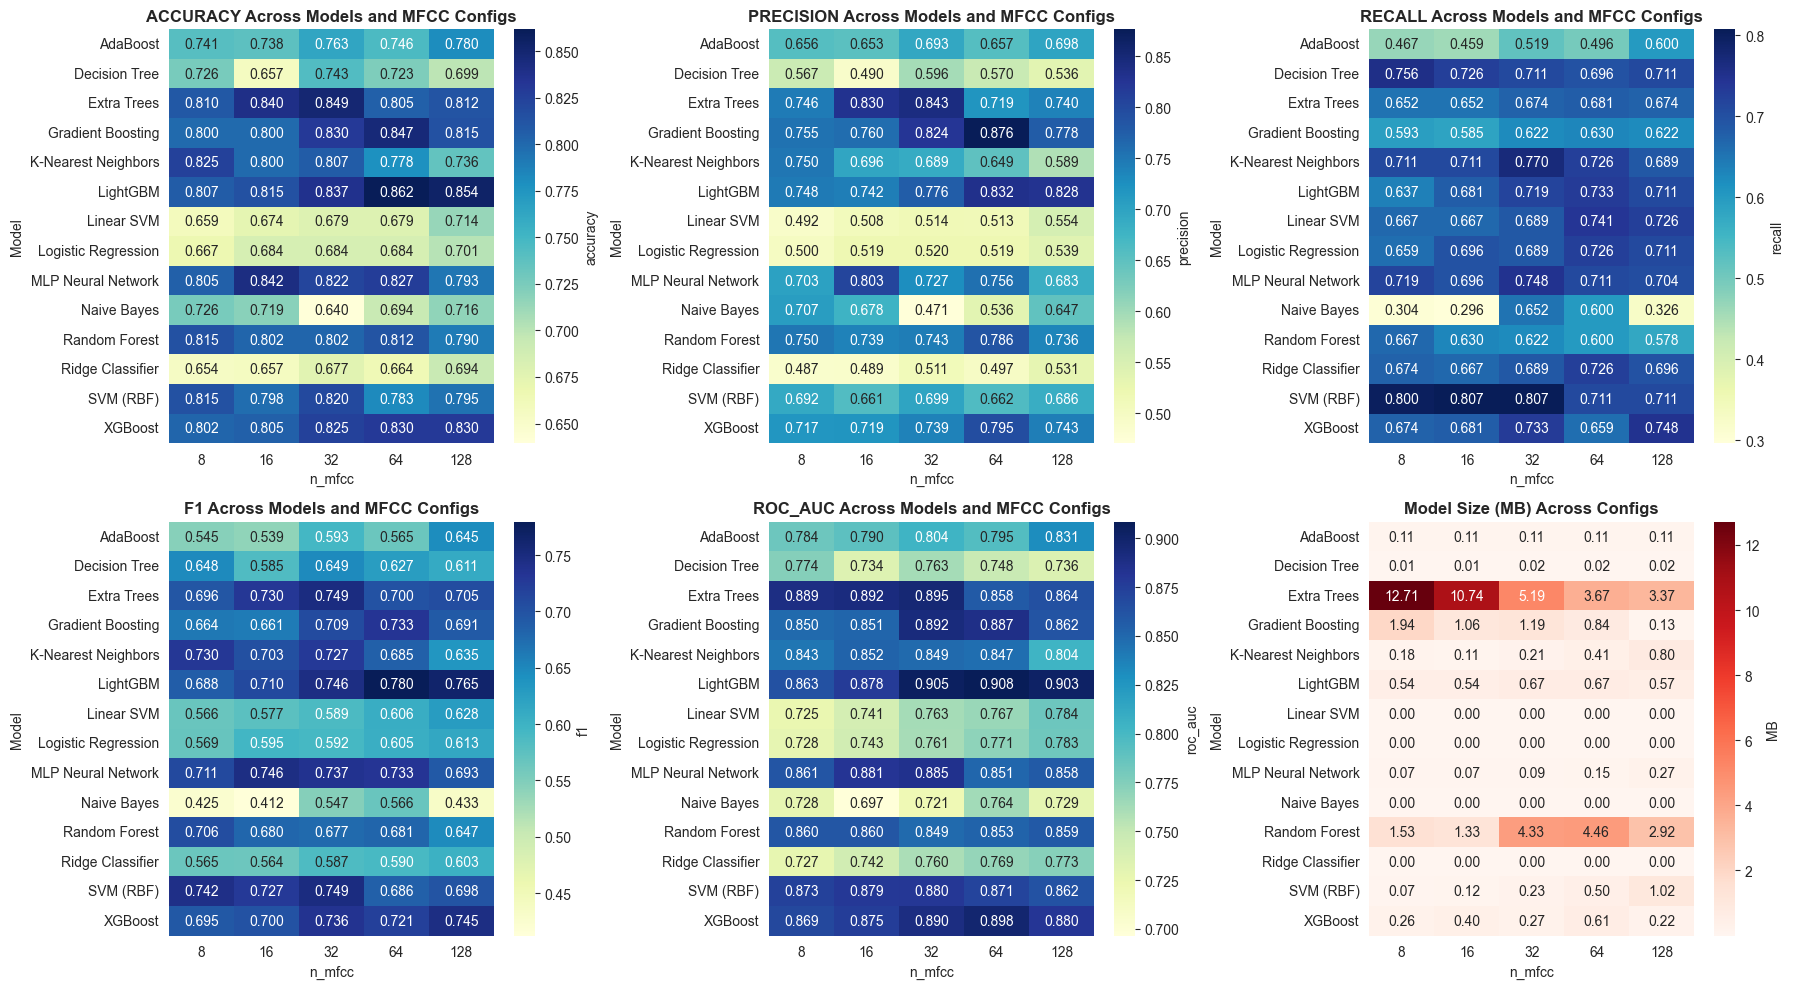

In [11]:
# Cell 11: Comprehensive Performance Comparison Heatmap
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    pivot = results_df.pivot_table(
        values=metric, 
        index='model_name', 
        columns='n_mfcc', 
        aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric.upper()} Across Models and MFCC Configs', fontsize=12, fontweight='bold')
    ax.set_xlabel('n_mfcc')
    ax.set_ylabel('Model')

# Model Size heatmap
ax = axes[1, 2]
pivot_size = results_df.pivot_table(
    values='model_size_mb', 
    index='model_name', 
    columns='n_mfcc', 
    aggfunc='mean'
)
sns.heatmap(pivot_size, annot=True, fmt='.2f', cmap='Reds', ax=ax, cbar_kws={'label': 'MB'})
ax.set_title('Model Size (MB) Across Configs', fontsize=12, fontweight='bold')
ax.set_xlabel('n_mfcc')
ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "performance_heatmaps.png"), dpi=300, bbox_inches='tight')
plt.show()

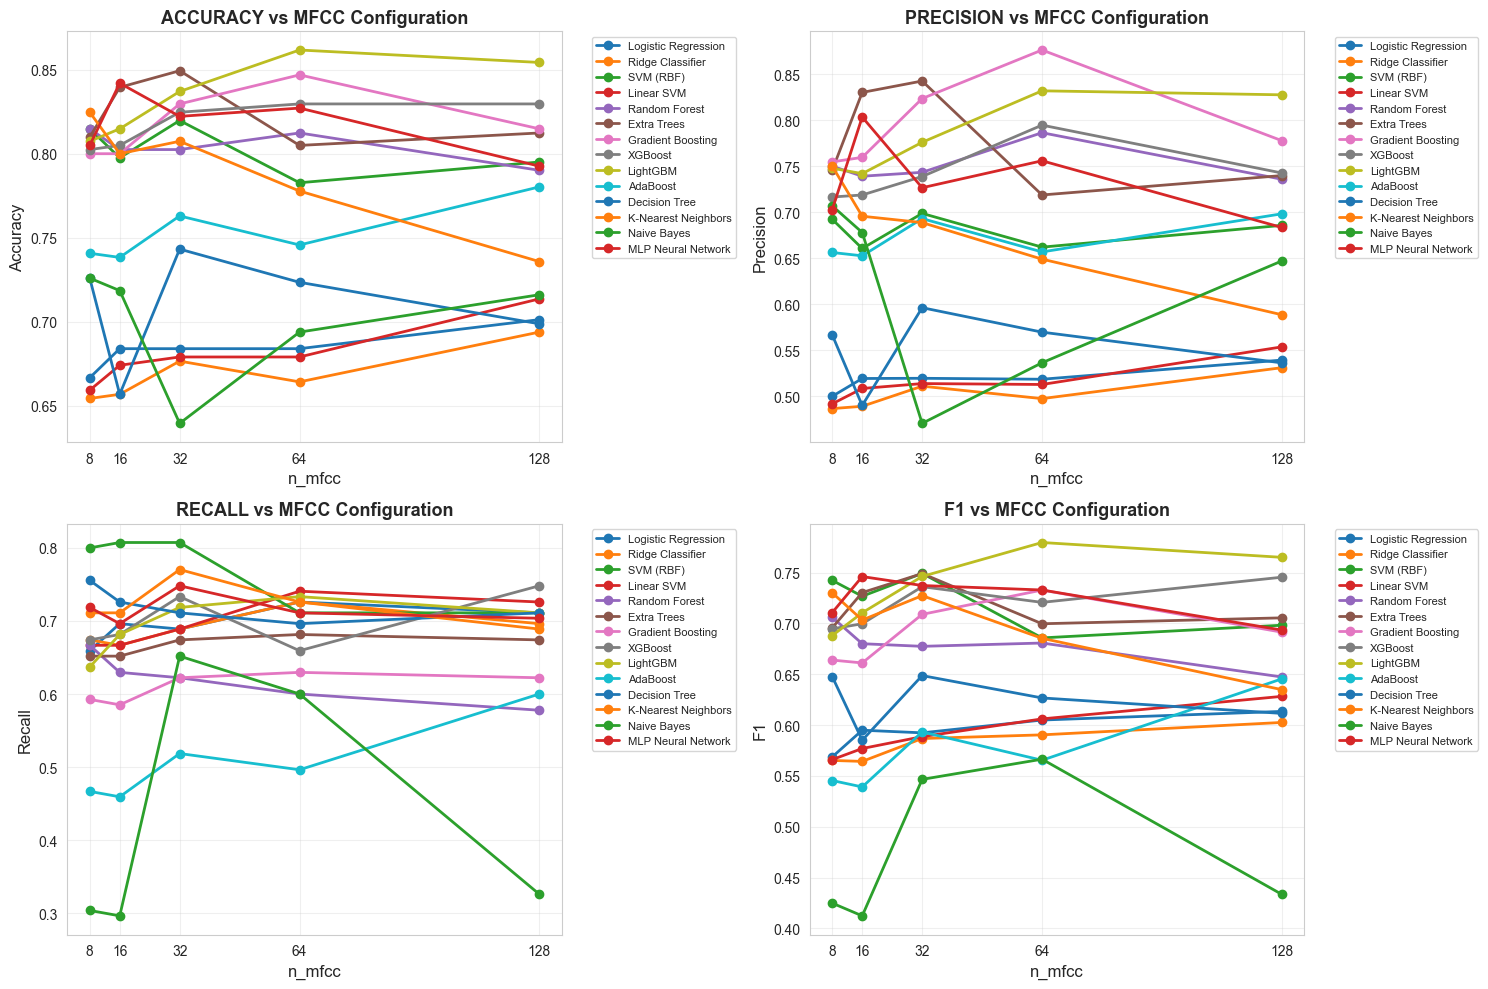

In [12]:
# Cell 12: Performance Metrics by MFCC Configuration
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    for model in results_df['model_name'].unique():
        model_data = results_df[results_df['model_name'] == model]
        ax.plot(model_data['n_mfcc'], model_data[metric], marker='o', label=model, linewidth=2)
    
    ax.set_xlabel('n_mfcc', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f'{metric.upper()} vs MFCC Configuration', fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(MFCC_LIST)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "metrics_by_mfcc.png"), dpi=300, bbox_inches='tight')
plt.show()

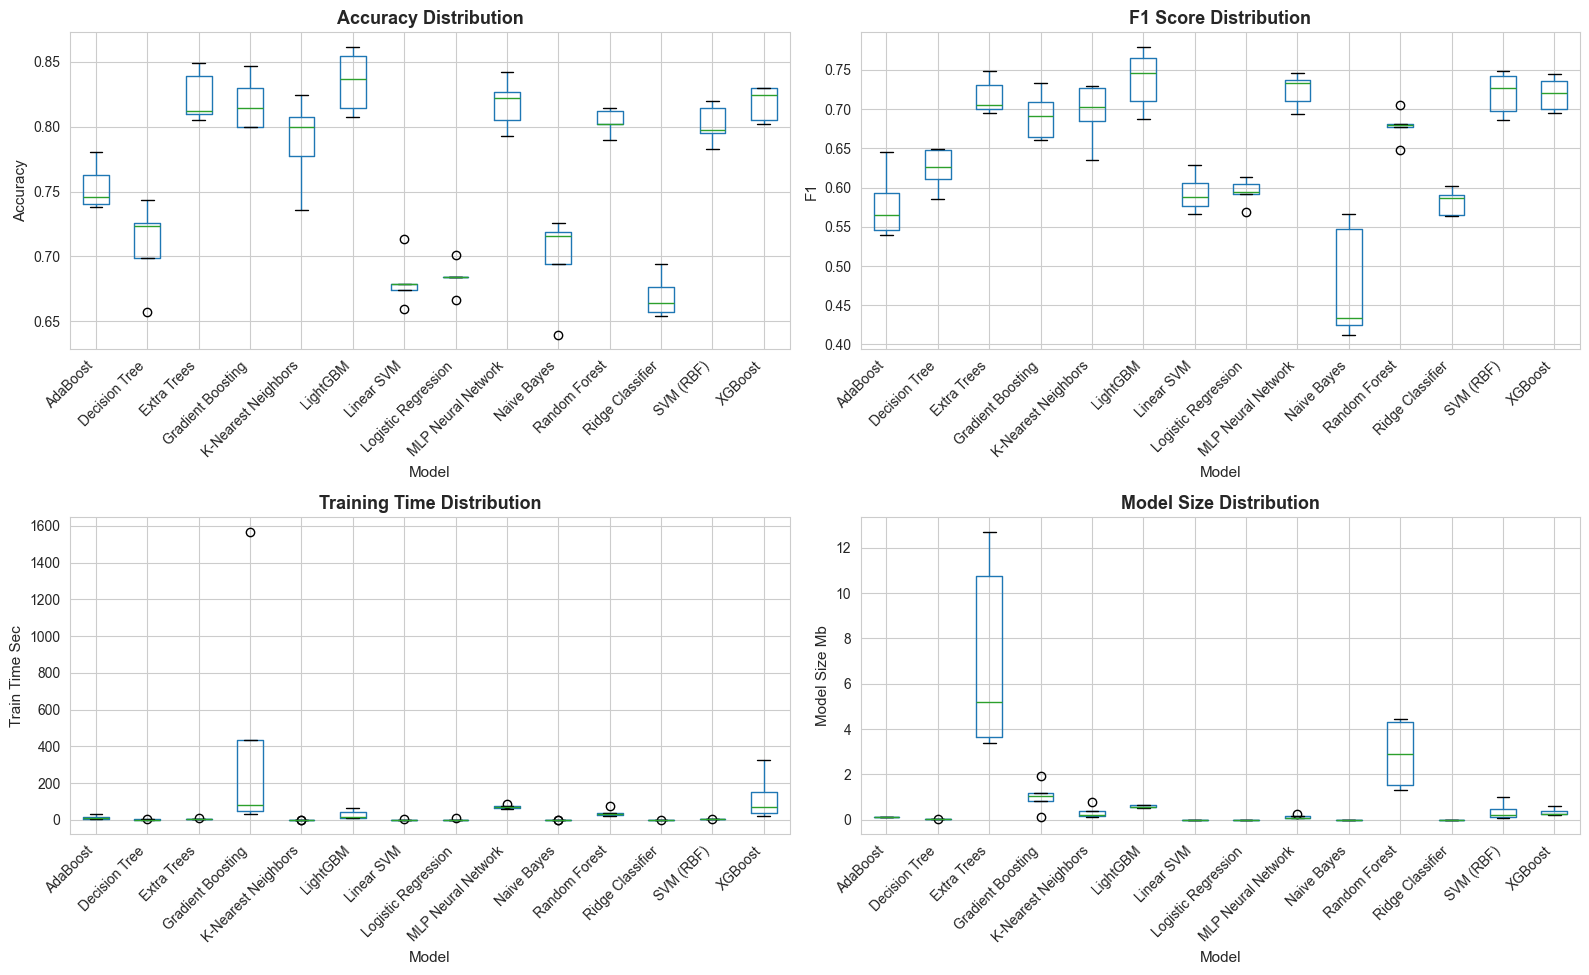

In [13]:
# Cell 13: Model Performance Distribution (Boxplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_box = ['accuracy', 'f1', 'train_time_sec', 'model_size_mb']
titles = ['Accuracy Distribution', 'F1 Score Distribution', 
          'Training Time Distribution', 'Model Size Distribution']

for idx, (metric, title) in enumerate(zip(metrics_box, titles)):
    ax = axes[idx // 2, idx % 2]
    
    results_df.boxplot(column=metric, by='model_name', ax=ax, rot=90)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "performance_distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

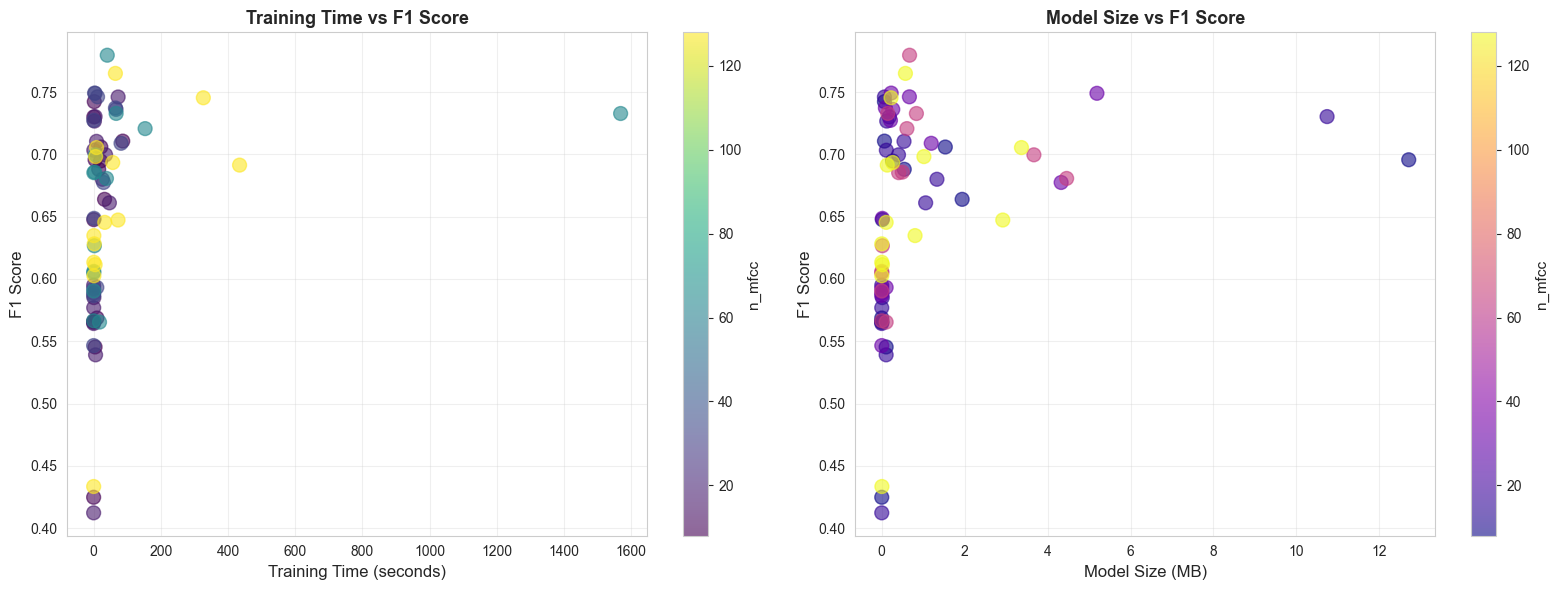

In [14]:
# Cell 14: Training Time vs Model Size vs Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Time vs F1 Score
ax = axes[0]
scatter = ax.scatter(results_df['train_time_sec'], results_df['f1'], 
                     c=results_df['n_mfcc'], s=100, alpha=0.6, cmap='viridis')
ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Training Time vs F1 Score', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('n_mfcc', fontsize=11)
ax.grid(True, alpha=0.3)

# Model Size vs F1 Score
ax = axes[1]
scatter = ax.scatter(results_df['model_size_mb'], results_df['f1'], 
                     c=results_df['n_mfcc'], s=100, alpha=0.6, cmap='plasma')
ax.set_xlabel('Model Size (MB)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Model Size vs F1 Score', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('n_mfcc', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "time_size_performance.png"), dpi=300, bbox_inches='tight')
plt.show()

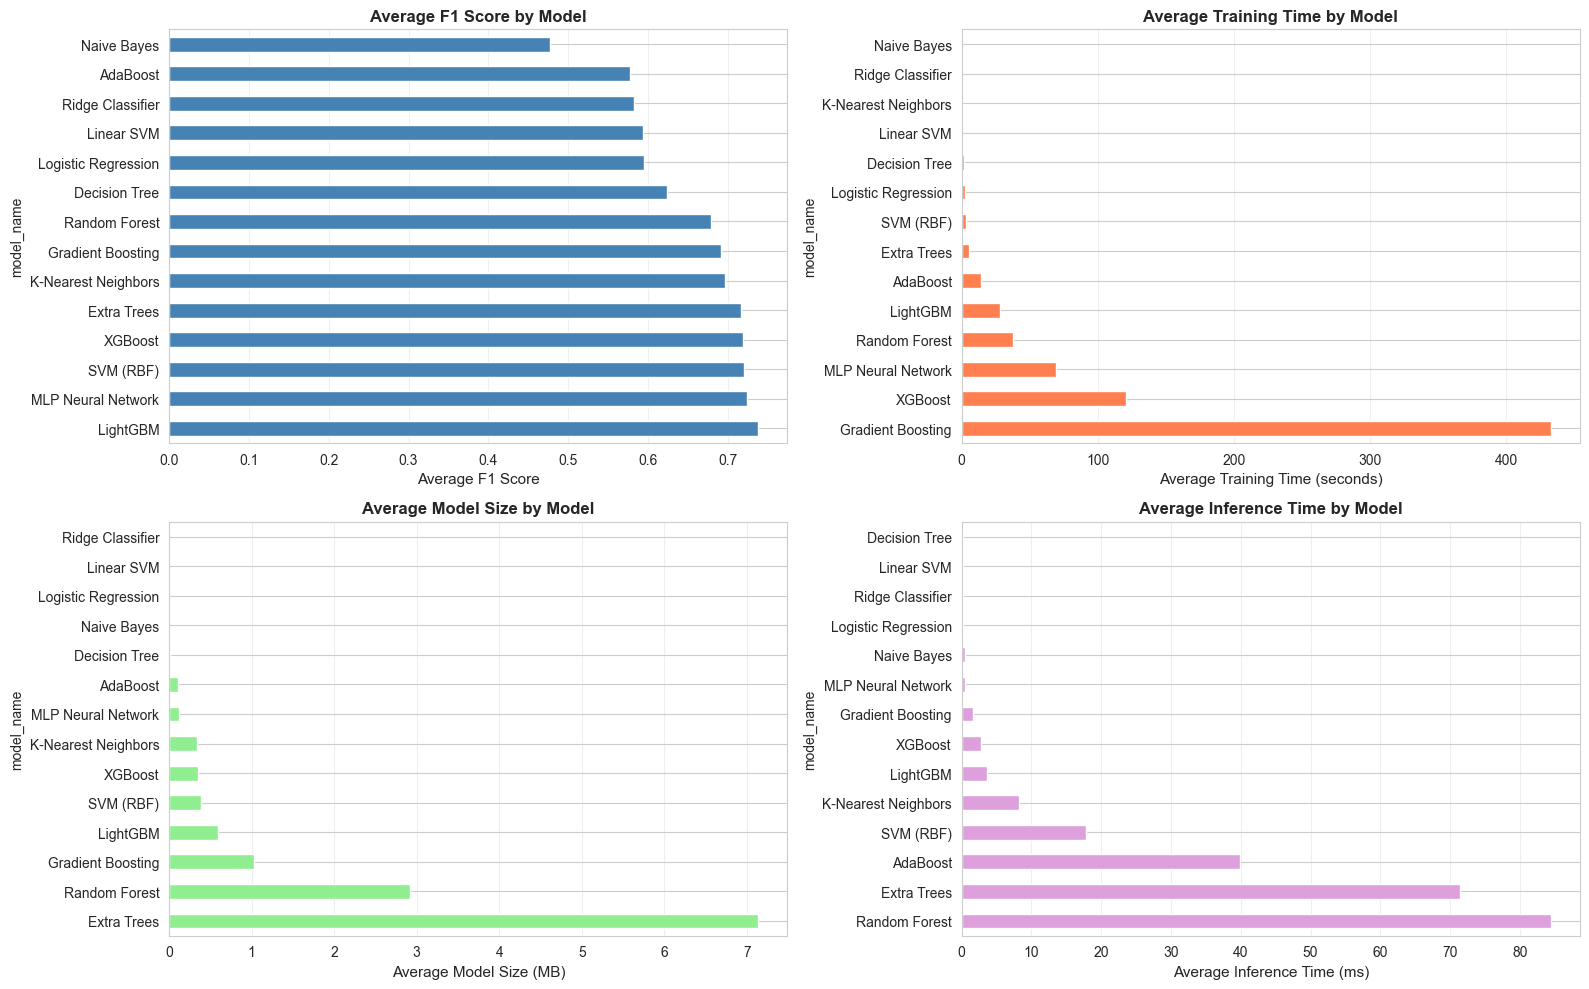

In [15]:
# Cell 15: Model Comparison Bar Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Average F1 Score per Model
ax = axes[0, 0]
avg_f1 = results_df.groupby('model_name')['f1'].mean().sort_values(ascending=False)
avg_f1.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average F1 Score', fontsize=11)
ax.set_title('Average F1 Score by Model', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Average Training Time per Model
ax = axes[0, 1]
avg_time = results_df.groupby('model_name')['train_time_sec'].mean().sort_values(ascending=False)
avg_time.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Average Training Time (seconds)', fontsize=11)
ax.set_title('Average Training Time by Model', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Average Model Size per Model
ax = axes[1, 0]
avg_size = results_df.groupby('model_name')['model_size_mb'].mean().sort_values(ascending=False)
avg_size.plot(kind='barh', ax=ax, color='lightgreen')
ax.set_xlabel('Average Model Size (MB)', fontsize=11)
ax.set_title('Average Model Size by Model', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Average Inference Time per Model
ax = axes[1, 1]
avg_inference = results_df.groupby('model_name')['inference_time_ms'].mean().sort_values(ascending=False)
avg_inference.plot(kind='barh', ax=ax, color='plum')
ax.set_xlabel('Average Inference Time (ms)', fontsize=11)
ax.set_title('Average Inference Time by Model', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_comparisons.png"), dpi=300, bbox_inches='tight')
plt.show()

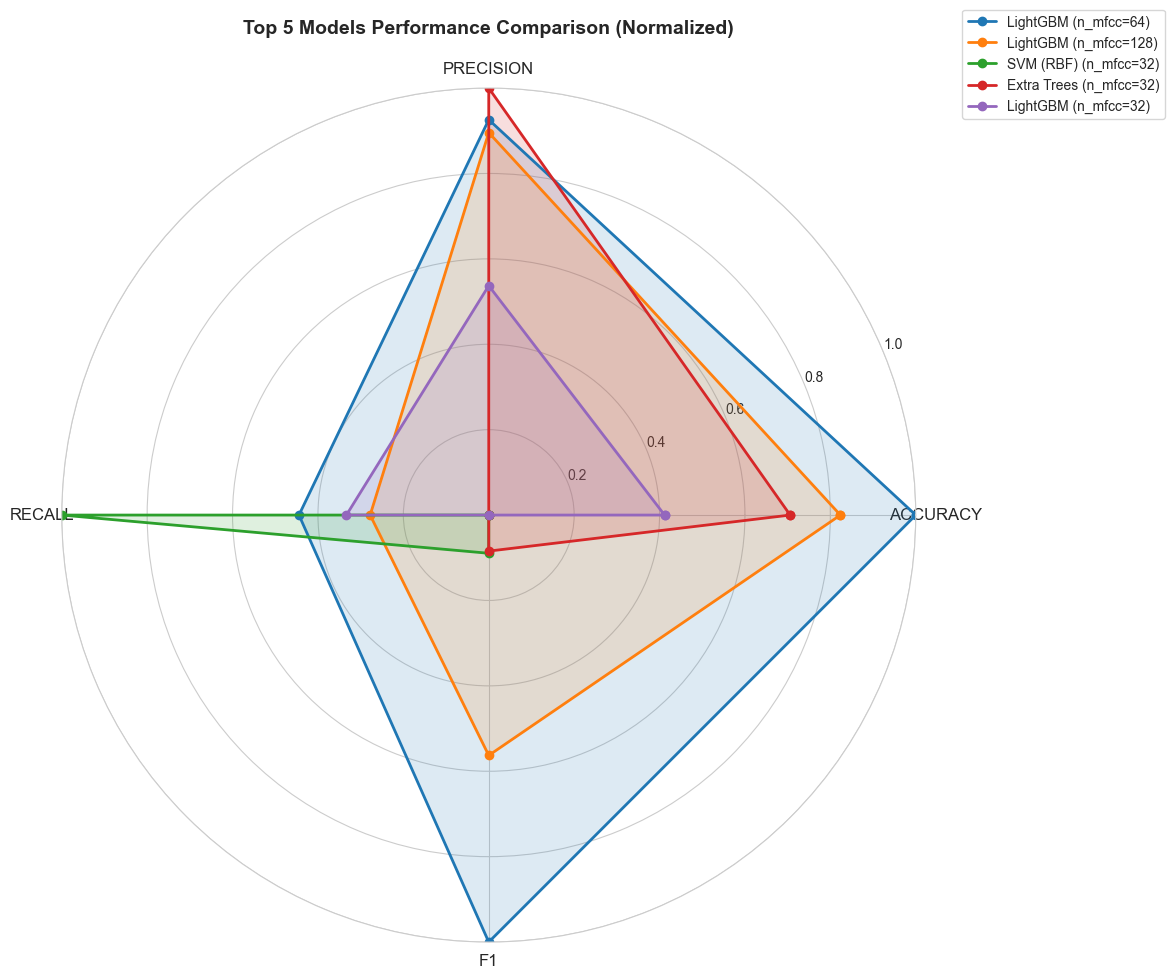

In [16]:
# Cell 16: Radar Chart for Top 5 Models
from math import pi

top_5_models = results_df.nlargest(5, 'f1')

# Normalize metrics to 0-1 scale for radar chart
metrics_radar = ['accuracy', 'precision', 'recall', 'f1']
normalized_data = top_5_models[metrics_radar].copy()

for col in metrics_radar:
    max_val = normalized_data[col].max()
    min_val = normalized_data[col].min()
    if max_val > min_val:
        normalized_data[col] = (normalized_data[col] - min_val) / (max_val - min_val)

# Create radar chart
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='polar')

angles = [n / float(len(metrics_radar)) * 2 * pi for n in range(len(metrics_radar))]
angles += angles[:1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (_, row) in enumerate(normalized_data.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    
    model_info = top_5_models.iloc[idx]
    label = f"{model_info['model_name']} (n_mfcc={model_info['n_mfcc']})"
    
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.upper() for m in metrics_radar], fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Top 5 Models Performance Comparison (Normalized)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "radar_chart_top5.png"), dpi=300, bbox_inches='tight')
plt.show()

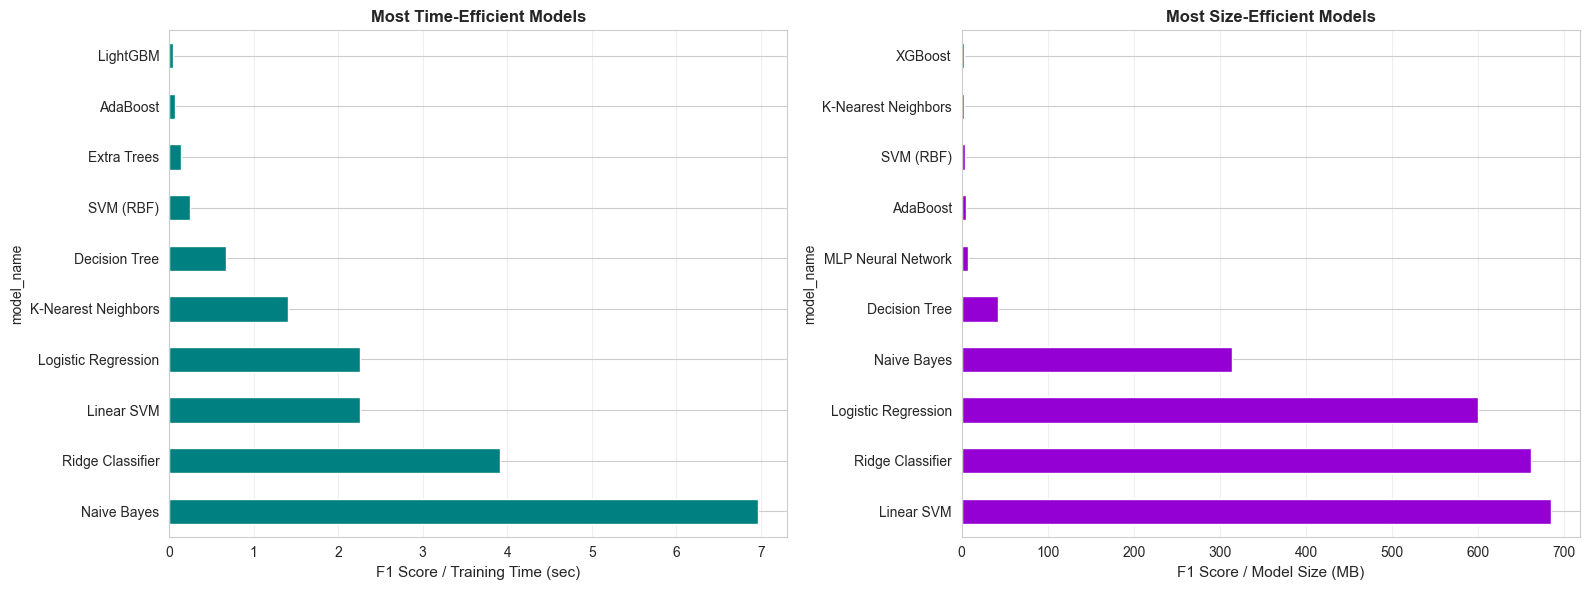

In [17]:
# Cell 17: Efficiency Analysis (F1 Score per Training Second)
results_df['efficiency'] = results_df['f1'] / (results_df['train_time_sec'] + 1e-6)
results_df['size_efficiency'] = results_df['f1'] / (results_df['model_size_mb'] + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time Efficiency
ax = axes[0]
eff_time = results_df.groupby('model_name')['efficiency'].mean().sort_values(ascending=False).head(10)
eff_time.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('F1 Score / Training Time (sec)', fontsize=11)
ax.set_title('Most Time-Efficient Models', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Size Efficiency
ax = axes[1]
eff_size = results_df.groupby('model_name')['size_efficiency'].mean().sort_values(ascending=False).head(10)
eff_size.plot(kind='barh', ax=ax, color='darkviolet')
ax.set_xlabel('F1 Score / Model Size (MB)', fontsize=11)
ax.set_title('Most Size-Efficient Models', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "efficiency_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Cell 18: Performance by MFCC - Detailed Comparison Table
print("\n" + "="*80)
print("PERFORMANCE STATISTICS BY MFCC CONFIGURATION")
print("="*80)

mfcc_summary = results_df.groupby('n_mfcc').agg({
    'accuracy': ['mean', 'std', 'max'],
    'precision': ['mean', 'std', 'max'],
    'recall': ['mean', 'std', 'max'],
    'f1': ['mean', 'std', 'max'],
    'train_time_sec': ['mean', 'sum'],
    'model_size_mb': ['mean', 'max']
}).round(4)

display(mfcc_summary)
mfcc_summary.to_csv(os.path.join(RESULTS_DIR, "mfcc_summary_statistics.csv"))


PERFORMANCE STATISTICS BY MFCC CONFIGURATION


accuracy                 precision                  recall          \
           mean     std     max      mean     std     max    mean     std   
n_mfcc                                                                      
8        0.7608  0.0639  0.8247    0.6620  0.1042  0.7547  0.6413  0.1240   
16       0.7593  0.0686  0.8420    0.6633  0.1171  0.8302  0.6397  0.1258   
32       0.7698  0.0719  0.8494    0.6673  0.1231  0.8426  0.6889  0.0718   
64       0.7667  0.0677  0.8617    0.6691  0.1282  0.8763  0.6741  0.0702   
128      0.7663  0.0546  0.8543    0.6634  0.0986  0.8276  0.6577  0.1075   

                    f1                 train_time_sec             \
           max    mean     std     max           mean        sum   
n_mfcc                                                             
8       0.8000  0.6392  0.0913  0.7423        14.1748   198.4467   
16      0.8074  0.6379  0.0953  0.7460        14.6154   204.6157   
32      0.8074  0.6705  0.0750  0.7491        19.5457   273.6402   
64      0.7407  0.6626  0.0687  0.7795       135.5268  1897.3756   
128     0.7481  0.6511  0.0804  0.7649        72.2860  1012.0033   

       model_size_mb           
                mean      max  
n_mfcc                         
8             1.2448  12.7085  
16            1.0354  10.7397  
32            0.8785   5.1900  
64            0.8159   4.4591  
128           0.6742   3.3702

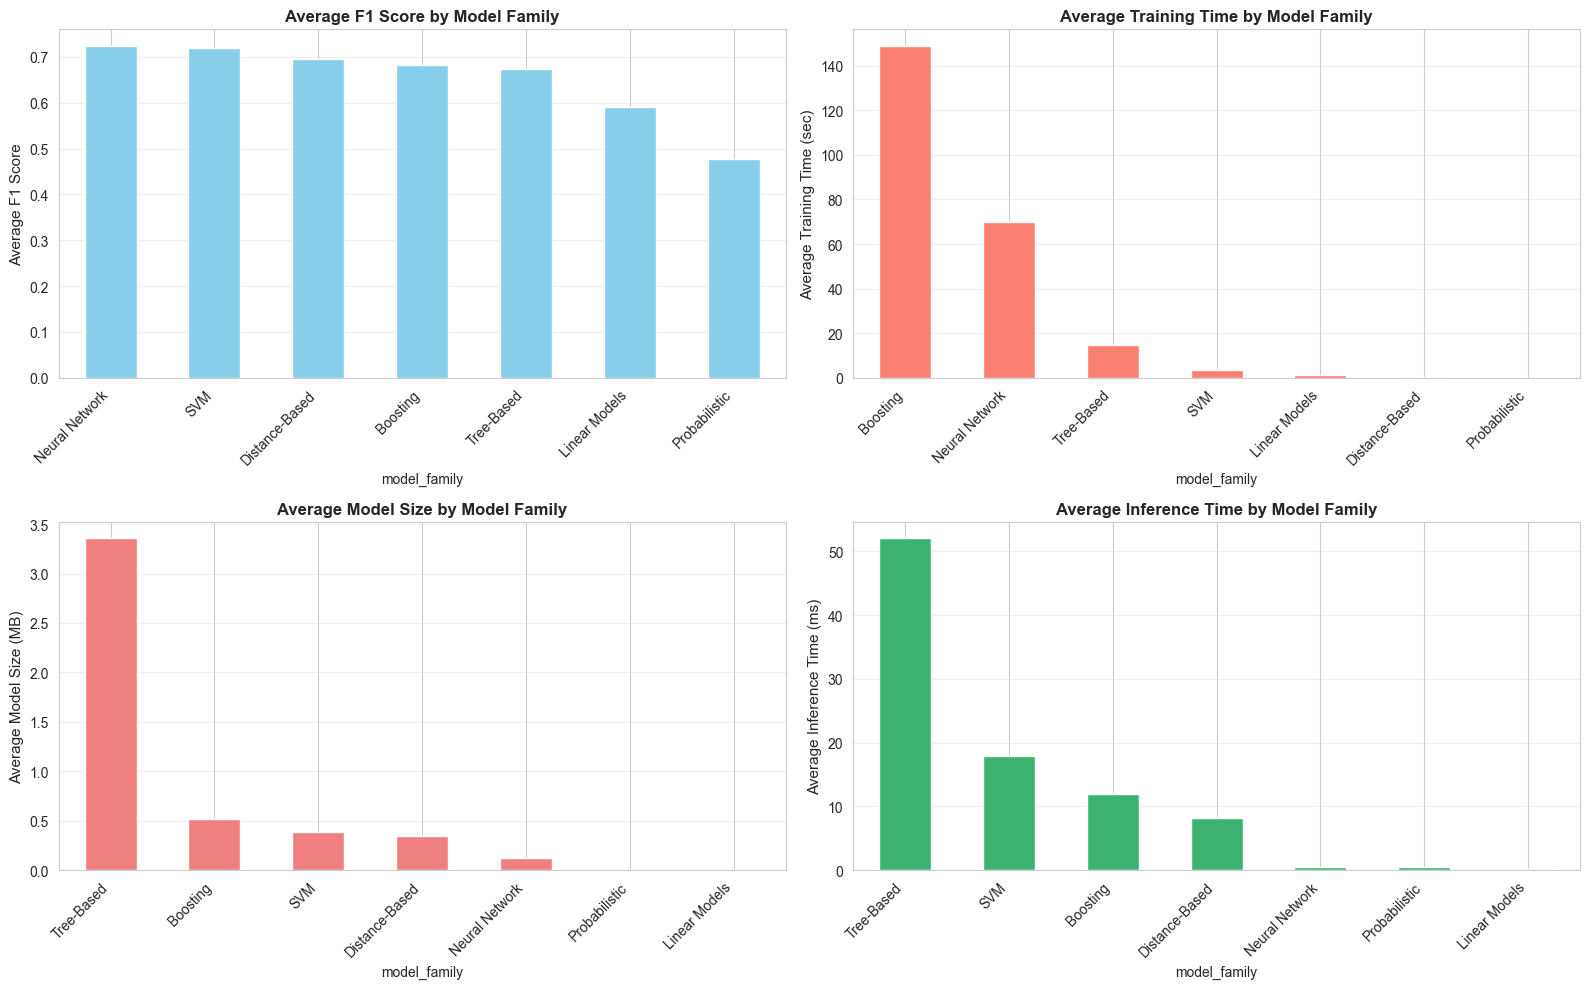

In [19]:
# Cell 19: Model Family Comparison
# Group models into families
model_families = {
    'Linear Models': ['Logistic Regression', 'Ridge Classifier', 'Linear SVM'],
    'SVM': ['SVM (RBF)', 'Linear SVM'],
    'Tree-Based': ['Decision Tree', 'Random Forest', 'Extra Trees'],
    'Boosting': ['Gradient Boosting', 'XGBoost', 'LightGBM', 'AdaBoost'],
    'Neural Network': ['MLP Neural Network'],
    'Distance-Based': ['K-Nearest Neighbors'],
    'Probabilistic': ['Naive Bayes']
}

results_df['model_family'] = results_df['model_name'].apply(
    lambda x: next((family for family, models in model_families.items() if x in models), 'Other')
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# F1 by Family
ax = axes[0, 0]
family_f1 = results_df.groupby('model_family')['f1'].mean().sort_values(ascending=False)
family_f1.plot(kind='bar', ax=ax, color='skyblue')
ax.set_ylabel('Average F1 Score', fontsize=11)
ax.set_title('Average F1 Score by Model Family', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Training Time by Family
ax = axes[0, 1]
family_time = results_df.groupby('model_family')['train_time_sec'].mean().sort_values(ascending=False)
family_time.plot(kind='bar', ax=ax, color='salmon')
ax.set_ylabel('Average Training Time (sec)', fontsize=11)
ax.set_title('Average Training Time by Model Family', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Model Size by Family
ax = axes[1, 0]
family_size = results_df.groupby('model_family')['model_size_mb'].mean().sort_values(ascending=False)
family_size.plot(kind='bar', ax=ax, color='lightcoral')
ax.set_ylabel('Average Model Size (MB)', fontsize=11)
ax.set_title('Average Model Size by Model Family', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Inference Time by Family
ax = axes[1, 1]
family_inference = results_df.groupby('model_family')['inference_time_ms'].mean().sort_values(ascending=False)
family_inference.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_ylabel('Average Inference Time (ms)', fontsize=11)
ax.set_title('Average Inference Time by Model Family', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_family_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


CORRELATION ANALYSIS


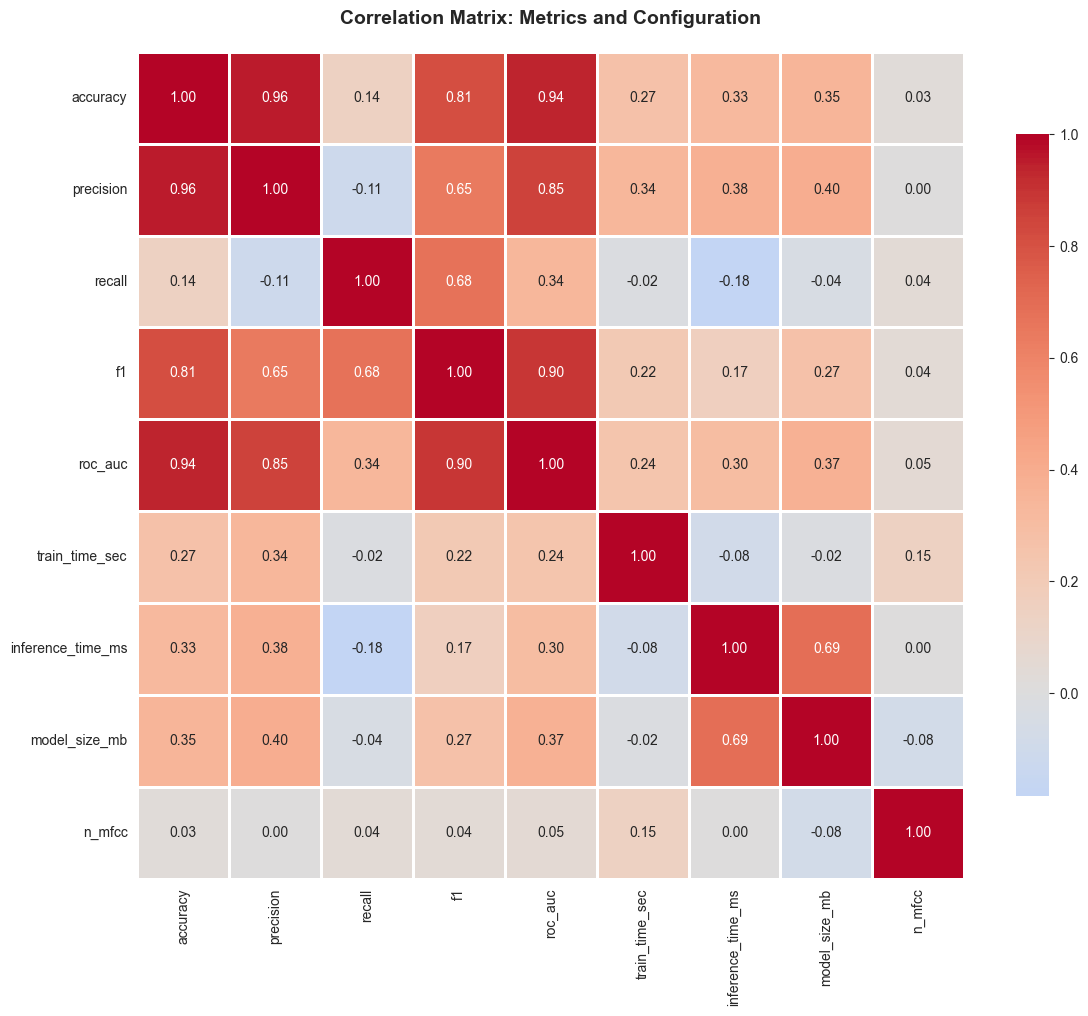

In [20]:
# Cell 20: Correlation Analysis
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

correlation_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 
                       'train_time_sec', 'inference_time_ms', 'model_size_mb', 'n_mfcc']
corr_matrix = results_df[correlation_metrics].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Metrics and Configuration', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

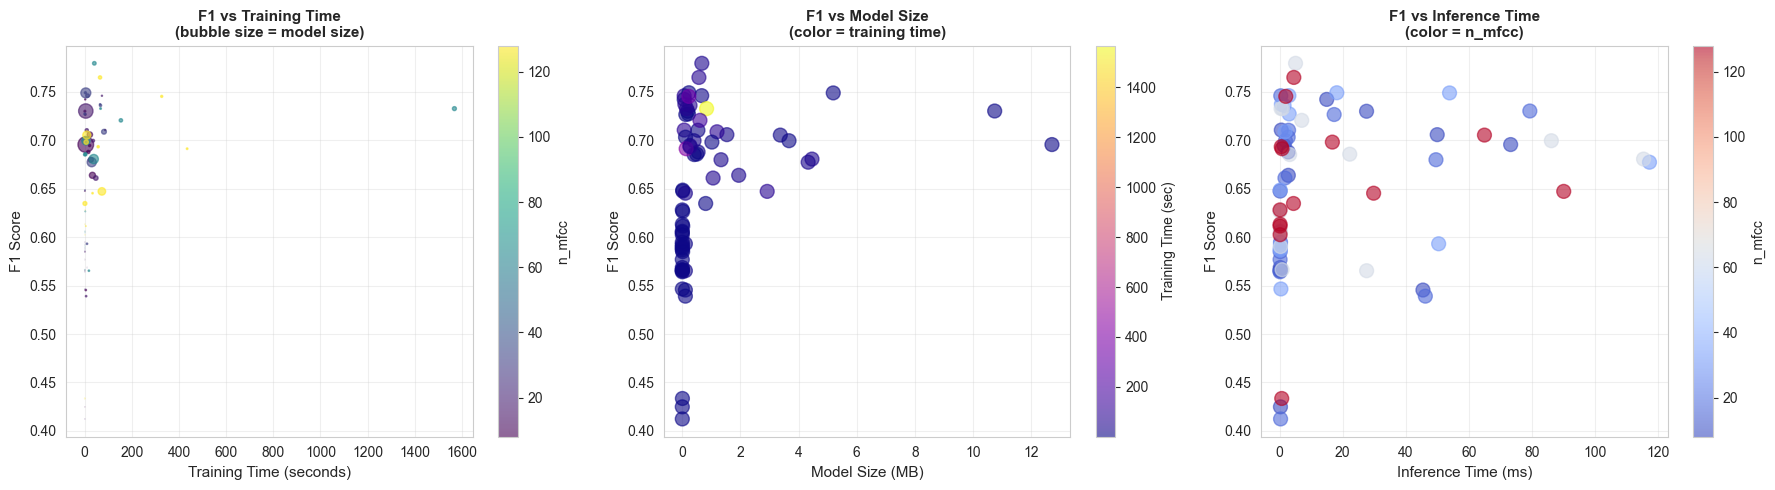

In [21]:
# Cell 21: Trade-off Analysis - Performance vs Efficiency
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# F1 vs Training Time (bubble size = model size)
ax = axes[0]
scatter = ax.scatter(results_df['train_time_sec'], results_df['f1'], 
                     s=results_df['model_size_mb']*10, 
                     c=results_df['n_mfcc'], alpha=0.6, cmap='viridis')
ax.set_xlabel('Training Time (seconds)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 vs Training Time\n(bubble size = model size)', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('n_mfcc', fontsize=10)
ax.grid(True, alpha=0.3)

# F1 vs Model Size (color = training time)
ax = axes[1]
scatter = ax.scatter(results_df['model_size_mb'], results_df['f1'], 
                     c=results_df['train_time_sec'], 
                     s=100, alpha=0.6, cmap='plasma')
ax.set_xlabel('Model Size (MB)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 vs Model Size\n(color = training time)', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Training Time (sec)', fontsize=10)
ax.grid(True, alpha=0.3)

# F1 vs Inference Time (color = n_mfcc)
ax = axes[2]
scatter = ax.scatter(results_df['inference_time_ms'], results_df['f1'], 
                     c=results_df['n_mfcc'], 
                     s=100, alpha=0.6, cmap='coolwarm')
ax.set_xlabel('Inference Time (ms)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 vs Inference Time\n(color = n_mfcc)', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('n_mfcc', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tradeoff_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()


PARETO OPTIMAL MODELS (F1 vs TRAINING TIME)


,model_name,n_mfcc,f1,accuracy,train_time_sec,model_size_mb,inference_time_ms
50,LightGBM,64,0.779528,0.861728,40.629585,0.671804,5.070097
30,SVM (RBF),32,0.749141,0.819753,2.844610,0.228390,18.136261
2,SVM (RBF),8,0.742268,0.814815,2.021601,0.066103,14.946027
11,K-Nearest Neighbors,8,0.730038,0.824691,0.553957,0.183795,27.558835
39,K-Nearest Neighbors,32,0.727273,0.807407,0.282274,0.210754,3.057120
42,Logistic Regression,64,0.604938,0.683951,0.223883,0.001188,0.241483
14,Logistic Regression,16,0.594937,0.683951,0.159441,0.000809,0.307950
28,Logistic Regression,32,0.592357,0.683951,0.153294,0.000937,0.286639
29,Ridge Classifier,32,0.586751,0.676543,0.131162,0.000825,0.234804
54,Naive Bayes,64,0.566434,0.693827,0.067006,0.002539,0.806171


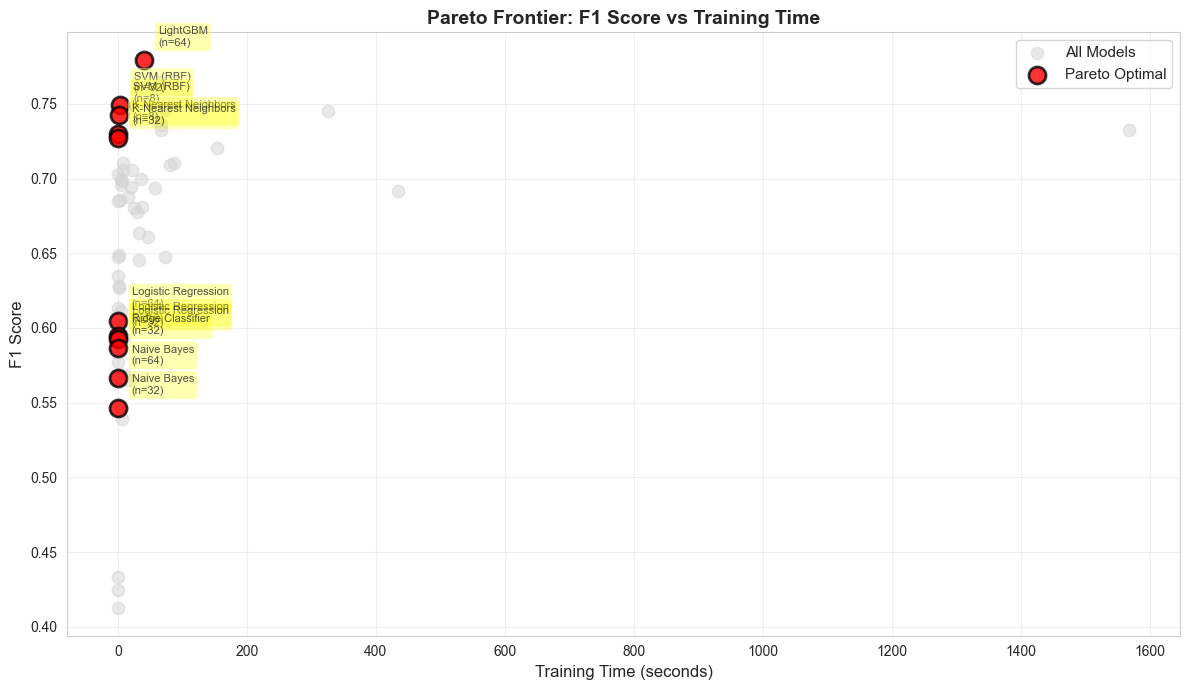

In [22]:
# Cell 22: Pareto Frontier Analysis (F1 vs Training Time)
print("\n" + "="*80)
print("PARETO OPTIMAL MODELS (F1 vs TRAINING TIME)")
print("="*80)

# Sort by F1 (descending) and training time (ascending)
pareto_candidates = results_df.sort_values(['f1', 'train_time_sec'], ascending=[False, True])

# Find Pareto frontier
pareto_front = []
min_time = float('inf')

for idx, row in pareto_candidates.iterrows():
    if row['train_time_sec'] < min_time:
        pareto_front.append(idx)
        min_time = row['train_time_sec']

pareto_models = results_df.loc[pareto_front].sort_values('f1', ascending=False)

display(pareto_models[['model_name', 'n_mfcc', 'f1', 'accuracy', 'train_time_sec', 
                        'model_size_mb', 'inference_time_ms']])

# Plot Pareto frontier
plt.figure(figsize=(12, 7))
plt.scatter(results_df['train_time_sec'], results_df['f1'], 
            alpha=0.5, s=80, label='All Models', color='lightgray')
plt.scatter(pareto_models['train_time_sec'], pareto_models['f1'], 
            alpha=0.8, s=150, label='Pareto Optimal', color='red', edgecolors='black', linewidths=2)

# Annotate Pareto optimal models
for idx, row in pareto_models.iterrows():
    plt.annotate(f"{row['model_name']}\n(n={row['n_mfcc']})", 
                 (row['train_time_sec'], row['f1']),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=8, alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Pareto Frontier: F1 Score vs Training Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pareto_frontier.png"), dpi=300, bbox_inches='tight')
plt.show()

pareto_models.to_csv(os.path.join(RESULTS_DIR, "pareto_optimal_models.csv"), index=False)

In [23]:
# Cell 23: Final Recommendations Summary
print("\n" + "="*100)
print("FINAL RECOMMENDATIONS")
print("="*100)

recommendations = {
    "Best Overall Performance": results_df.nlargest(1, 'f1'),
    "Best Accuracy": results_df.nlargest(1, 'accuracy'),
    "Fastest Training": results_df.nsmallest(1, 'train_time_sec'),
    "Smallest Model": results_df.nsmallest(1, 'model_size_mb'),
    "Fastest Inference": results_df.nsmallest(1, 'inference_time_ms'),
    "Best Time Efficiency": results_df.nlargest(1, 'efficiency'),
    "Best Size Efficiency": results_df.nlargest(1, 'size_efficiency')
}

for category, model_row in recommendations.items():
    print(f"\n{category}:")
    print("-" * 100)
    model_info = model_row.iloc[0]
    print(f"  Model: {model_info['model_name']}")
    print(f"  n_mfcc: {model_info['n_mfcc']}")
    print(f"  F1 Score: {model_info['f1']:.4f}")
    print(f"  Accuracy: {model_info['accuracy']:.4f}")
    print(f"  Training Time: {model_info['train_time_sec']:.2f} sec")
    print(f"  Model Size: {model_info['model_size_mb']:.4f} MB")
    print(f"  Inference Time: {model_info['inference_time_ms']:.4f} ms")
    print(f"  Best Params: {model_info['best_params']}")

# Save recommendations
recommendations_df = pd.concat([df.assign(Category=cat) for cat, df in recommendations.items()])
recommendations_df.to_csv(os.path.join(RESULTS_DIR, "final_recommendations.csv"), index=False)


FINAL RECOMMENDATIONS

Best Overall Performance:
----------------------------------------------------------------------------------------------------
  Model: LightGBM
  n_mfcc: 64
  F1 Score: 0.7795
  Accuracy: 0.8617
  Training Time: 40.63 sec
  Model Size: 0.6718 MB
  Inference Time: 5.0701 ms
  Best Params: {'learning_rate': 0.1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}

Best Accuracy:
----------------------------------------------------------------------------------------------------
  Model: LightGBM
  n_mfcc: 64
  F1 Score: 0.7795
  Accuracy: 0.8617
  Training Time: 40.63 sec
  Model Size: 0.6718 MB
  Inference Time: 5.0701 ms
  Best Params: {'learning_rate': 0.1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}

Fastest Training:
----------------------------------------------------------------------------------------------------
  Model: Naive Bayes
  n_mfcc: 32
  F1 Score: 0.5466
  Accuracy: 0.6395
  Training Time: 0.05 sec
  Model Size: 

In [25]:
# Cell 25: Export Final Summary Report
print("\n" + "="*100)
print("GENERATING FINAL SUMMARY REPORT")
print("="*100)

summary_report = {
    "Total Experiments": len(results_df),
    "Models Tested": results_df['model_name'].nunique(),
    "MFCC Configurations": len(MFCC_LIST),
    "Best Overall F1": results_df['f1'].max(),
    "Best Overall Accuracy": results_df['accuracy'].max(),
    "Average F1": results_df['f1'].mean(),
    "Average Accuracy": results_df['accuracy'].mean(),
    "Total Training Time (hours)": results_df['train_time_sec'].sum() / 3600,
    "Average Training Time (sec)": results_df['train_time_sec'].mean(),
    "Average Model Size (MB)": results_df['model_size_mb'].mean(),
    "Average Inference Time (ms)": results_df['inference_time_ms'].mean()
}

summary_df = pd.DataFrame([summary_report]).T
summary_df.columns = ['Value']
display(summary_df)

summary_df.to_csv(os.path.join(RESULTS_DIR, "summary_report.csv"))

print(f"\n{'='*100}")
print("ALL RESULTS SAVED TO:")
print(f"  Directory: {RESULTS_DIR}")
print(f"  Main Results: all_results.csv")
print(f"  Top Models: top_10_models.csv")
print(f"  Best per MFCC: best_per_mfcc.csv")
print(f"  Best per Model: best_per_model.csv")
print(f"  Recommendations: final_recommendations.csv")
print(f"  Pareto Optimal: pareto_optimal_models.csv")
print(f"  Summary Report: summary_report.csv")
print(f"  Log File: {log_file}")
print(f"{'='*100}")

logger.info("\n" + "="*80)
logger.info("PIPELINE COMPLETED SUCCESSFULLY")
logger.info(f"Total experiments: {len(results_df)}")
logger.info(f"Results saved to: {RESULTS_DIR}")
logger.info("="*80)


GENERATING FINAL SUMMARY REPORT


,Value
Total Experiments,70.000000
Models Tested,14.000000
MFCC Configurations,5.000000
Best Overall F1,0.779528
Best Overall Accuracy,0.861728
Average F1,0.652266
Average Accuracy,0.764586
Total Training Time (hours),0.996134
Average Training Time (sec),51.229737
Average Model Size (MB),0.929761



ALL RESULTS SAVED TO:
  Directory: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results
  Main Results: all_results.csv
  Top Models: top_10_models.csv
  Best per MFCC: best_per_mfcc.csv
  Best per Model: best_per_model.csv
  Recommendations: final_recommendations.csv
  Pareto Optimal: pareto_optimal_models.csv
  Summary Report: summary_report.csv
  Log File: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results\training_log_20251011_163634.log
2025-10-11 17:38:50,890 - INFO - 
2025-10-11 17:38:50,891 - INFO - PIPELINE COMPLETED SUCCESSFULLY
2025-10-11 17:38:50,893 - INFO - Total experiments: 70
2025-10-11 17:38:50,895 - INFO - Results saved to: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\model_results
2025-10-11 17:38:50,897 - INFO - ================================================================================
2025-10-11 17:38:50,